# COS30019 Assignment 2B — Traffic Forecasting with LSTM
## Notebook 03: LSTM Model Training & Evaluation

**Purpose:** Train a single LSTM model on data from **all SCATS approaches**, then
evaluate both in aggregate and per-intersection on held-out test data.

**Input:** `../data/processed/scats_wide.parquet`  
**Splits:** chronological 70 / 15 / 15 % (train / val / test) — applied independently per approach  
**Target:** predict next 15-min volume given the previous 12 intervals (3 hours)

---
## 1. Imports & Config

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch  {torch.__version__}")
print(f"NumPy    {np.__version__}")
print(f"pandas   {pd.__version__}")
print(f"Device   {device}")

# ── Reproducibility ────────────────────────────────   ──────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if device.type == "cuda":
    torch.cuda.manual_seed(SEED)

# ── Hyperparameters ───────────────────────────────────────────────────────────
LOOKBACK     = 12    # 12 x 15 min = 3 hours of history
HORIZON      = 1     # predict the next single interval
BATCH_SIZE   = 32
EPOCHS       = 50
LSTM_UNITS = 64
MIN_COVERAGE = 0.5   # skip approaches with < 50 % non-NaN data

# ── Sliding-window helper ─────────────────────────────────────────────────────
def make_windows(arr, lookback=LOOKBACK, horizon=HORIZON):
    n_samples = len(arr) - lookback - horizon + 1
    X = np.array([arr[i : i + lookback]                     for i in range(n_samples)])
    y = np.array([arr[i + lookback : i + lookback + horizon] for i in range(n_samples)])
    return X, y

PyTorch  2.12.0+cpu
NumPy    2.4.3
pandas   3.0.2
Device   cpu


---
## 2. Load Data

In [3]:
wide_df = pd.read_parquet("../data/processed/scats_wide.parquet")
print(f"Wide DataFrame : {wide_df.shape}  (timestamps × approaches)")
print(f"Date range     : {wide_df.index[0]}  →  {wide_df.index[-1]}")
print(f"Approaches     : {wide_df.shape[1]}")

Wide DataFrame : (2976, 139)  (timestamps × approaches)
Date range     : 2006-10-01 00:00:00  →  2006-10-31 23:45:00
Approaches     : 139


---
## 3. Pre-processing: Scale → Split → Window (all approaches)

In [4]:
all_X_train, all_y_train = [], []
all_X_val,   all_y_val   = [], []
all_X_test,  all_y_test  = [], []

scalers   = {}   # col → fitted MinMaxScaler (needed for per-intersection eval)
kept_cols = []   # approaches that passed the coverage filter

skipped = 0
for col in wide_df.columns:
    series = wide_df[col].dropna().values.astype(np.float32)
    if len(series) / len(wide_df) < MIN_COVERAGE:
        skipped += 1
        continue

    n         = len(series)
    train_end = int(n * 0.70)
    val_end   = int(n * 0.85)

    train_raw = series[:train_end]
    val_raw   = series[train_end:val_end]
    test_raw  = series[val_end:]

    # Fit scaler on train only — no data leakage
    scaler   = MinMaxScaler(feature_range=(0, 1))
    train_sc = scaler.fit_transform(train_raw.reshape(-1, 1)).flatten()
    val_sc   = scaler.transform(val_raw.reshape(-1,   1)).flatten()
    test_sc  = scaler.transform(test_raw.reshape(-1,  1)).flatten()

    X_tr, y_tr = make_windows(train_sc)
    X_v,  y_v  = make_windows(val_sc)
    X_te, y_te = make_windows(test_sc)

    if len(X_tr) == 0 or len(X_te) == 0:
        skipped += 1
        continue

    all_X_train.append(X_tr);  all_y_train.append(y_tr)
    all_X_val.append(X_v);     all_y_val.append(y_v)
    all_X_test.append(X_te);   all_y_test.append(y_te)
    scalers[col]   = scaler
    kept_cols.append(col)

print(f"Approaches kept : {len(kept_cols)}  (skipped {skipped})")

# Stack all sliding-window samples ────────────────────────────────────────────
X_train = np.concatenate(all_X_train)[..., np.newaxis]
y_train = np.concatenate(all_y_train)
X_val   = np.concatenate(all_X_val)[..., np.newaxis]
y_val   = np.concatenate(all_y_val)
X_test  = np.concatenate(all_X_test)[..., np.newaxis]
y_test  = np.concatenate(all_y_test)

# Shuffle train so batches see a mix of intersections
rng = np.random.default_rng(SEED)
idx = rng.permutation(len(X_train))
X_train, y_train = X_train[idx], y_train[idx]

print(f"\nCombined window shapes  (samples, timesteps, features):")
print(f"  X_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"  X_val   : {X_val.shape}    y_val   : {y_val.shape}")
print(f"  X_test  : {X_test.shape}    y_test  : {y_test.shape}")

Approaches kept : 138  (skipped 1)

Combined window shapes  (samples, timesteps, features):
  X_train : (277790, 12, 1)   y_train : (277790, 1)
  X_val   : (58196, 12, 1)    y_val   : (58196, 1)
  X_test  : (58310, 12, 1)    y_test  : (58310, 1)


---
## 4. Build the LSTM Model

In [5]:
class TrafficLSTM(nn.Module):
    def __init__(self, lstm_units=LSTM_UNITS, horizon=HORIZON):
        super().__init__()
        self.lstm1 = nn.LSTM(input_size=1, hidden_size=lstm_units, batch_first=True)
        self.drop1 = nn.Dropout(0.2)
        self.lstm2 = nn.LSTM(input_size=lstm_units, hidden_size=lstm_units // 2, batch_first=True)
        self.drop2 = nn.Dropout(0.2)
        self.fc = nn.Linear(lstm_units // 2, horizon)

    def forward(self, x):
        x, _ = self.lstm1(x)          # (B, 12, 64)
        x = self.drop1(x)
        x, _ = self.lstm2(x)          # (B, 12, 32)
        x = self.drop2(x[:, -1, :])   # last timestep → (B, 32)
        return self.fc(x)             # (B, 1)

model = TrafficLSTM().to(device)
total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTotal params: {total_params:,}")

TrafficLSTM(
  (lstm1): LSTM(1, 64, batch_first=True)
  (drop1): Dropout(p=0.2, inplace=False)
  (lstm2): LSTM(64, 32, batch_first=True)
  (drop2): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

Total params: 29,729


---
## 5. Train

In [6]:
from tqdm.auto import tqdm
# ── DataLoaders ───────────────────────────────────────────────────────────────
def to_loader(X, y, shuffle=False):
    ds = TensorDataset(torch.FloatTensor(X), torch.FloatTensor(y))
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle,
                      pin_memory=(device.type == "cuda"))

train_dl = to_loader(X_train, y_train, shuffle=True)
val_dl   = to_loader(X_val,   y_val)

# ── Optimiser, loss, scheduler ────────────────────────────────────────────────
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, factor=0.5, patience=4, min_lr=1e-5
)

# ── Training loop ─────────────────────────────────────────────────────────────
history = {"loss": [], "val_loss": [], "mae": [], "val_mae": []}
best_val_loss  = float("inf")
best_weights   = None
patience_count = 0
PATIENCE       = 8

for epoch in range(EPOCHS):
    model.train()
    t_loss = t_mae = 0.0
    train_iter = tqdm(train_dl, desc=f"Epoch {epoch+1}/{EPOCHS} [train]", leave=False)
    for xb, yb in train_iter:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        t_loss += loss.item() * len(xb)
        t_mae  += (pred - yb).abs().sum().item()
        train_iter.set_postfix(loss=loss.item())   # live loss on the bar

    model.eval()
    v_loss = v_mae = 0.0
    with torch.no_grad():
        for xb, yb in tqdm(val_dl, desc=f"Epoch {epoch+1}/{EPOCHS} [val]", leave=False):
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            v_loss += criterion(pred, yb).item() * len(xb)
            v_mae  += (pred - yb).abs().sum().item()


    n_tr, n_v = len(train_dl.dataset), len(val_dl.dataset)
    t_loss /= n_tr;  t_mae /= n_tr
    v_loss /= n_v;   v_mae /= n_v

    history["loss"].append(t_loss);      history["mae"].append(t_mae)
    history["val_loss"].append(v_loss);  history["val_mae"].append(v_mae)

    scheduler.step(v_loss)
    lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch+1:3d}/{EPOCHS}  loss={t_loss:.4f}  mae={t_mae:.4f}  "
          f"val_loss={v_loss:.4f}  val_mae={v_mae:.4f}  lr={lr:.2e}")

    if v_loss < best_val_loss:
        best_val_loss  = v_loss
        best_weights   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

model.load_state_dict(best_weights)
print(f"\nBest val_loss: {best_val_loss:.4f}  (stopped at epoch {len(history['loss'])})")

Epoch 1/50 [train]:   0%|          | 0/8681 [00:00<?, ?it/s]

Epoch 1/50 [val]:   0%|          | 0/1819 [00:00<?, ?it/s]

Epoch   1/50  loss=0.0058  mae=0.0533  val_loss=0.0042  val_mae=0.0454  lr=1.00e-03


Epoch 2/50 [train]:   0%|          | 0/8681 [00:00<?, ?it/s]

Epoch 2/50 [val]:   0%|          | 0/1819 [00:00<?, ?it/s]

...

Epoch 49/50 [val]:   0%|          | 0/1819 [00:00<?, ?it/s]

Epoch  49/50  loss=0.0042  mae=0.0464  val_loss=0.0037  val_mae=0.0412  lr=1.25e-04


Epoch 50/50 [train]:   0%|          | 0/8681 [00:00<?, ?it/s]

Epoch 50/50 [val]:   0%|          | 0/1819 [00:00<?, ?it/s]

Epoch  50/50  loss=0.0042  mae=0.0464  val_loss=0.0037  val_mae=0.0415  lr=1.25e-04

Best val_loss: 0.0037  (stopped at epoch 50)


---
## 6. Training Curves

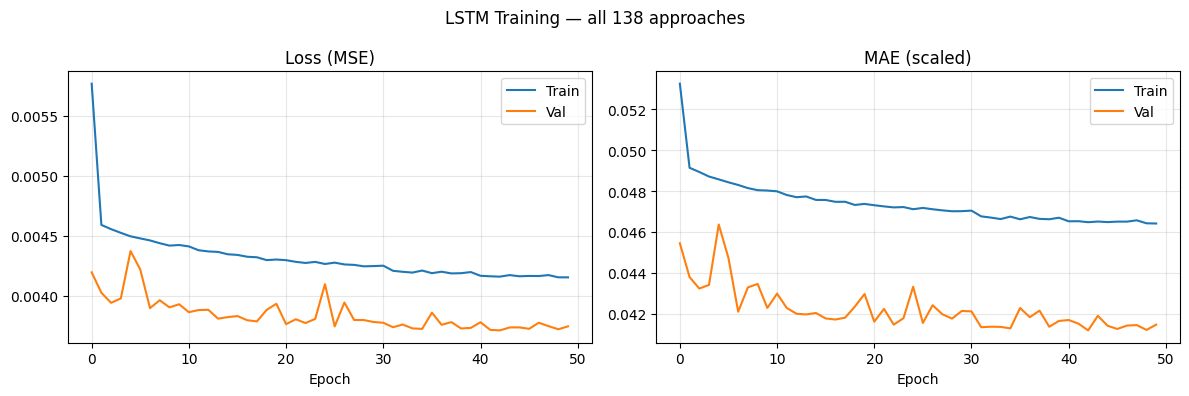

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["loss"],     label="Train")
axes[0].plot(history["val_loss"], label="Val")
axes[0].set_title("Loss (MSE)")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history["mae"],     label="Train")
axes[1].plot(history["val_mae"], label="Val")
axes[1].set_title("MAE (scaled)")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle(f"LSTM Training — all {len(kept_cols)} approaches")
fig.tight_layout()
plt.savefig("../data/processed/plot_lstm_training.png", dpi=120)
plt.show()

---
## 7. Evaluate on Test Set — Aggregate + Per-Intersection

In [8]:
def predict(X_np, batch_size=1024):
    model.eval()
    X_t = torch.FloatTensor(X_np).to(device)
    preds = []
    with torch.no_grad():
        for i in range(0, len(X_t), batch_size):
            preds.append(model(X_t[i:i+batch_size]).cpu().numpy())
    return np.concatenate(preds)

# ── Per-intersection evaluation ───────────────────────────────────────────────
per_col_metrics = []

for col in kept_cols:
    series   = wide_df[col].dropna().values.astype(np.float32)
    n        = len(series)
    val_end  = int(n * 0.85)
    test_raw = series[val_end:]

    scaler   = scalers[col]
    test_sc  = scaler.transform(test_raw.reshape(-1, 1)).flatten()
    X_c, y_c = make_windows(test_sc)
    if len(X_c) == 0:
        continue

    pred_sc  = predict(X_c[..., np.newaxis])
    pred_inv = scaler.inverse_transform(pred_sc).flatten()
    true_inv = scaler.inverse_transform(y_c).flatten()

    mae  = mean_absolute_error(true_inv, pred_inv)
    rmse = np.sqrt(mean_squared_error(true_inv, pred_inv))
    mape = np.mean(np.abs((true_inv - pred_inv) / np.where(true_inv == 0, 1, true_inv))) * 100
    per_col_metrics.append({"approach": col, "MAE": mae, "RMSE": rmse, "MAPE": mape})

metrics_df = pd.DataFrame(per_col_metrics).set_index("approach")

print(f"Per-intersection metrics (vehicle counts / 15 min) — {len(metrics_df)} approaches")
print(f"  Mean  MAE  : {metrics_df['MAE'].mean():.2f}")
print(f"  Mean  RMSE : {metrics_df['RMSE'].mean():.2f}")
print(f"  Mean  MAPE : {metrics_df['MAPE'].mean():.2f} %")
print(f"  Median MAE : {metrics_df['MAE'].median():.2f}")
print(f"\nBest 5 (lowest MAE):\n{metrics_df.nsmallest(5, 'MAE')[['MAE','RMSE','MAPE']].to_string()}")
print(f"\nWorst 5 (highest MAE):\n{metrics_df.nlargest(5, 'MAE')[['MAE','RMSE','MAPE']].to_string()}")

Per-intersection metrics (vehicle counts / 15 min) — 138 approaches
  Mean  MAE  : 12.99
  Mean  RMSE : 18.04
  Mean  MAPE : 36.24 %
  Median MAE : 12.32

Best 5 (lowest MAE):
                                         MAE      RMSE       MAPE
approach                                                         
4821__WALMER_ST N OF VICTORIA_ST    2.169774  3.277530  95.302200
2846__WILLS_ST NW OF HIGH_ST        2.726070  4.036652  71.046066
4051__SEVERN_ST S of DONCASTER_RD   2.892667  4.359456  43.679665
4030__KILBY_RD W of BURKE_RD        3.698959  5.147221  41.706001
4324__GLENFERRIE_RD S OF COTHAM_RD  6.992163  9.617148  33.661728

Worst 5 (highest MAE):
                                              MAE       RMSE        MAPE
approach                                                                
3001__BARKERS_RD W of CHURCH_ST         45.847878  64.585249  107.483910
3001__BARKERS_RD E of HIGH_ST           32.031006  47.720814   52.298157
3812__CAMBERWELL_RD SE of TRAFALGAR_RD  28.073

---
## 8. Predictions vs Actual — Best, Median & Worst Intersection

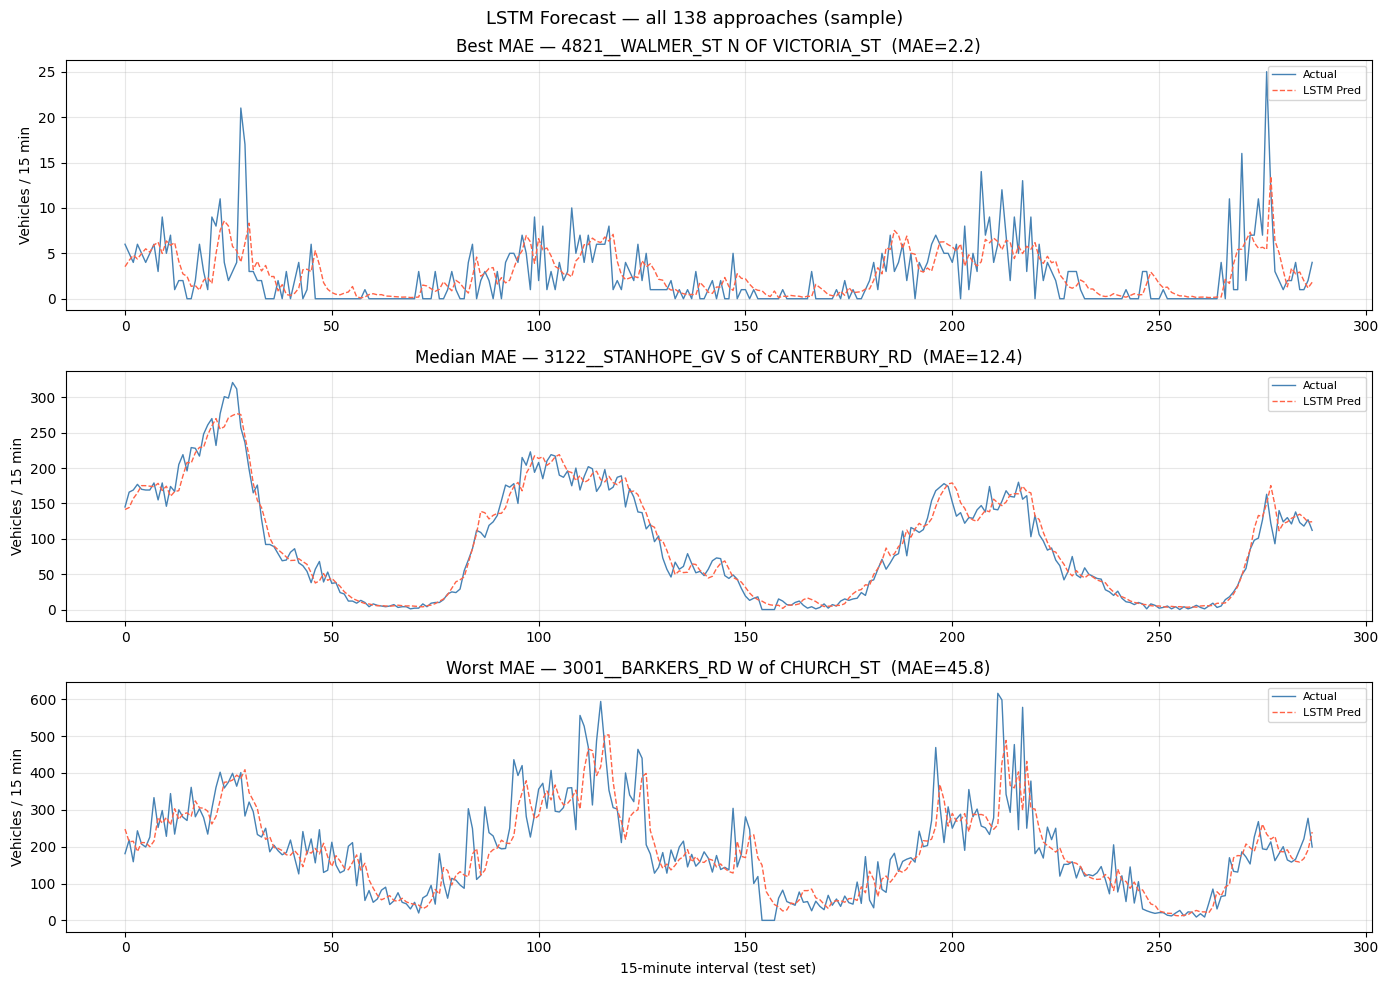

In [9]:
sorted_cols = metrics_df.sort_values("MAE")
sample_cols = [
    sorted_cols.index[0],
    sorted_cols.index[len(sorted_cols) // 2],
    sorted_cols.index[-1],
]
labels = ["Best MAE", "Median MAE", "Worst MAE"]
N_SHOW = 96 * 3  # 3 days

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

for ax, col, label in zip(axes, sample_cols, labels):
    series   = wide_df[col].dropna().values.astype(np.float32)
    n        = len(series)
    val_end  = int(n * 0.85)
    test_raw = series[val_end:]

    scaler   = scalers[col]
    test_sc  = scaler.transform(test_raw.reshape(-1, 1)).flatten()
    X_c, y_c = make_windows(test_sc)

    pred_sc  = predict(X_c[..., np.newaxis])
    pred_inv = scaler.inverse_transform(pred_sc).flatten()
    true_inv = scaler.inverse_transform(y_c).flatten()

    show    = min(N_SHOW, len(true_inv))
    mae_val = metrics_df.loc[col, "MAE"]

    ax.plot(true_inv[:show], label="Actual",   linewidth=1.0, color="steelblue")
    ax.plot(pred_inv[:show], label="LSTM Pred", linewidth=1.0, color="tomato", linestyle="--")
    ax.set_title(f"{label} — {col}  (MAE={mae_val:.1f})")
    ax.set_ylabel("Vehicles / 15 min")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("15-minute interval (test set)")
fig.suptitle(f"LSTM Forecast — all {len(kept_cols)} approaches (sample)", fontsize=13)
fig.tight_layout()
plt.savefig("../data/processed/plot_lstm_predictions.png", dpi=120)
plt.show()

In [10]:
torch.save(model.state_dict(), "../data/processed/lstm_model.pt")